# Readmission for Healthcare Analysis

## Initial Exploration

This notebook loads the dataset and performs initial exploration to understand its structure, variables, and data quality.  

# Team Members

- Michael Ryan
- Roy Phelps - Data exploration, project setup, and data analytics
- Shelby Frisbie
- Saad Majid

## Purpose of the Analysis

Hospital readmissions are an important quality metric in healthcare because they often indicate complications, insufficient follow-up care, or ineffective discharge planning. Reducing unnecessary readmissions improves patient outcomes while reducing healthcare costs.

The goal of this project is to identify the characteristics associated with 30-day hospital readmissions using exploratory data analysis and machine learning techniques. By understanding which patient factors are associated with readmission, healthcare providers may be able to identify high-risk patients earlier and improve clinical decision making.

This exploratory analysis establishes the foundation for future predictive modeling by evaluating the quality, structure, and usefulness of the available dataset.

# Description of the Dataset

The datasets' fields include

- patient id
- admission date
- season
- age
- gender
- region
- primary diagnosis
- comorbidities count **(condition that the patient has, ex: stroke, hypertension etc..)**
- length of stay
- treatement type
- medications count
- follow up visits prev. year
- insurance type
- discharge disposition
- readmission risk score
- label **(readmitted in the past 30 days binary, 1 = yes, 0 = no)**

# Exploratory Data Analysis

The purpose of exploratory data analysis (EDA) is to understand the overall structure of the dataset before developing predictive models. During this phase we examine data quality, summarize important variables, identify patterns, evaluate relationships between variables, and determine whether the dataset is appropriate for continued analysis.

In [69]:
# Imports
import pandas as pd
import numpy as np

# Uncomment for first install
#!pip install openpyxl

In [71]:
# Read in the dataset and view the first 5 entries
df = pd.read_csv("../data/raw/hospital_readmission_dataset.csv")
df.head()

,patient_id,admission_date,season,age,gender,region,primary_diagnosis,comorbidities_count,length_of_stay,treatment_type,medications_count,followup_visits_last_year,prev_readmissions,insurance_type,discharge_disposition,readmission_risk_score,label
0,P00001,2022-04-14,Spring,66,Male,South,Diabetes,5,6,Interventional,8,6,1,Medicare,Home Health,0.92,1
1,P00002,2021-09-19,Fall,55,Male,South,Diabetes,4,6,Interventional,6,4,3,Private,Home Health,0.88,1
2,P00003,2023-04-12,Spring,69,Female,West,Hypertension,6,8,Medical,9,6,2,Medicare,Skilled Nursing,0.97,1
3,P00004,2023-08-14,Summer,83,Male,South,Stroke,6,11,Medical,11,4,2,Medicare,Skilled Nursing,0.97,1
4,P00005,2021-11-05,Fall,54,Female,North,Stroke,4,10,Medical,6,2,1,Uninsured,Home Health,0.83,1


# Dataset Structure

We start by examining the size, structure, metrics, missing values of the dataset

In [74]:
# Dataset shape
df.shape

(8000, 17)

In [76]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   patient_id                 8000 non-null   object 
 1   admission_date             8000 non-null   object 
 2   season                     8000 non-null   object 
 3   age                        8000 non-null   int64  
 4   gender                     8000 non-null   object 
 5   region                     8000 non-null   object 
 6   primary_diagnosis          8000 non-null   object 
 7   comorbidities_count        8000 non-null   int64  
 8   length_of_stay             8000 non-null   int64  
 9   treatment_type             8000 non-null   object 
 10  medications_count          8000 non-null   int64  
 11  followup_visits_last_year  8000 non-null   int64  
 12  prev_readmissions          8000 non-null   int64  
 13  insurance_type             8000 non-null   objec

In [78]:
# Dataset metrics
df.describe()

,age,comorbidities_count,length_of_stay,medications_count,followup_visits_last_year,prev_readmissions,readmission_risk_score,label
count,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.00000,8000.000000,8000.000000
mean,57.411625,4.318500,7.789125,7.475750,3.638125,1.57250,0.776937,0.772875
std,16.724388,1.358046,1.930252,2.287917,1.630415,0.89196,0.219885,0.419000
min,18.000000,1.000000,3.000000,2.000000,0.000000,0.00000,0.070000,0.000000
25%,46.000000,3.000000,6.000000,6.000000,2.000000,1.00000,0.630000,1.000000
50%,57.000000,4.000000,8.000000,8.000000,4.000000,1.00000,0.860000,1.000000
75%,69.000000,5.000000,9.000000,9.000000,4.000000,2.00000,0.970000,1.000000
max,95.000000,10.000000,15.000000,18.000000,10.000000,5.00000,0.970000,1.000000


In [19]:
# Check missing values
df.isnull().sum()

patient_id                   0
admission_date               0
season                       0
age                          0
gender                       0
region                       0
primary_diagnosis            0
comorbidities_count          0
length_of_stay               0
treatment_type               0
medications_count            0
followup_visits_last_year    0
prev_readmissions            0
insurance_type               0
discharge_disposition        0
readmission_risk_score       0
label                        0
dtype: int64

In [21]:
# Check duplicate rows
df.duplicated().sum()

0

### Interpretation
No missing values were identified within the dataset. Because every observation contains complete information, no additional preprocessing such as imputation or record removal is required prior to model development.

The descriptive statistics provide a summary of the numerical variables within the dataset. These statistics allow us to better understand the distribution, variability, and range of each feature while identifying potential outliers that may require further investigation.

No duplicate records were identified. This indicates that each patient encounter appears to represent a unique observation, reducing the likelihood of duplicated information influencing the analysis.

In [23]:
# Target variable distribution
df['label'].value_counts()
df['label'].value_counts(normalize=True) * 100

label
1    77.2875
0    22.7125
Name: proportion, dtype: float64

### Interpretation
After checking the target variable distribution, the split is almost 80 / 20.

array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'comorbidities_count'}>,
        <Axes: title={'center': 'length_of_stay'}>],
       [<Axes: title={'center': 'medications_count'}>,
        <Axes: title={'center': 'followup_visits_last_year'}>,
        <Axes: title={'center': 'prev_readmissions'}>],
       [<Axes: title={'center': 'readmission_risk_score'}>,
        <Axes: title={'center': 'label'}>, <Axes: >]], dtype=object)

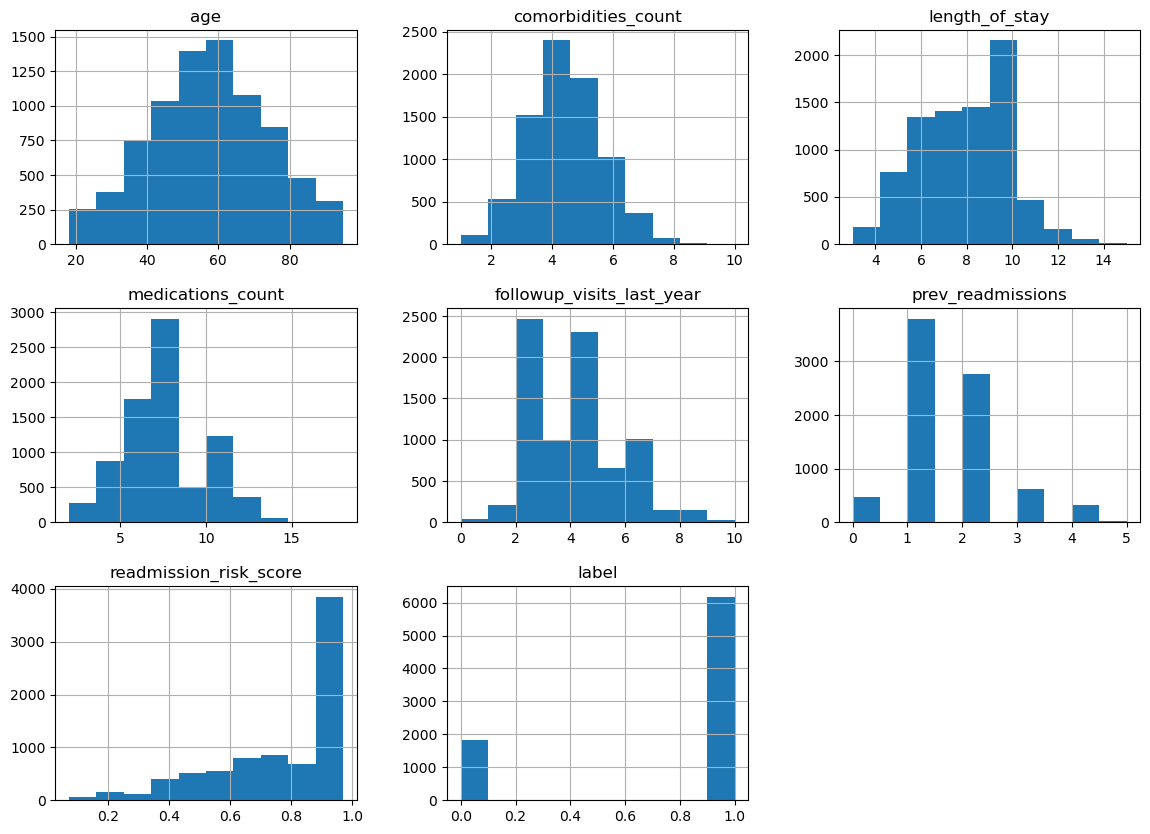

In [26]:
# Histograms for numaric values
df.hist(figsize=(14,10))

### Interpretation

The histograms illustrate the distributions of the numerical variables. Several variables appear approximately normally distributed while others exhibit skewness or clustering around common values. Understanding these distributions will assist with selecting appropriate preprocessing techniques and predictive models.

(array([1, 2, 3, 4, 5, 6, 7, 8]),
 [Text(1, 0, 'age'),
  Text(2, 0, 'comorbidities_count'),
  Text(3, 0, 'length_of_stay'),
  Text(4, 0, 'medications_count'),
  Text(5, 0, 'followup_visits_last_year'),
  Text(6, 0, 'prev_readmissions'),
  Text(7, 0, 'readmission_risk_score'),
  Text(8, 0, 'label')])

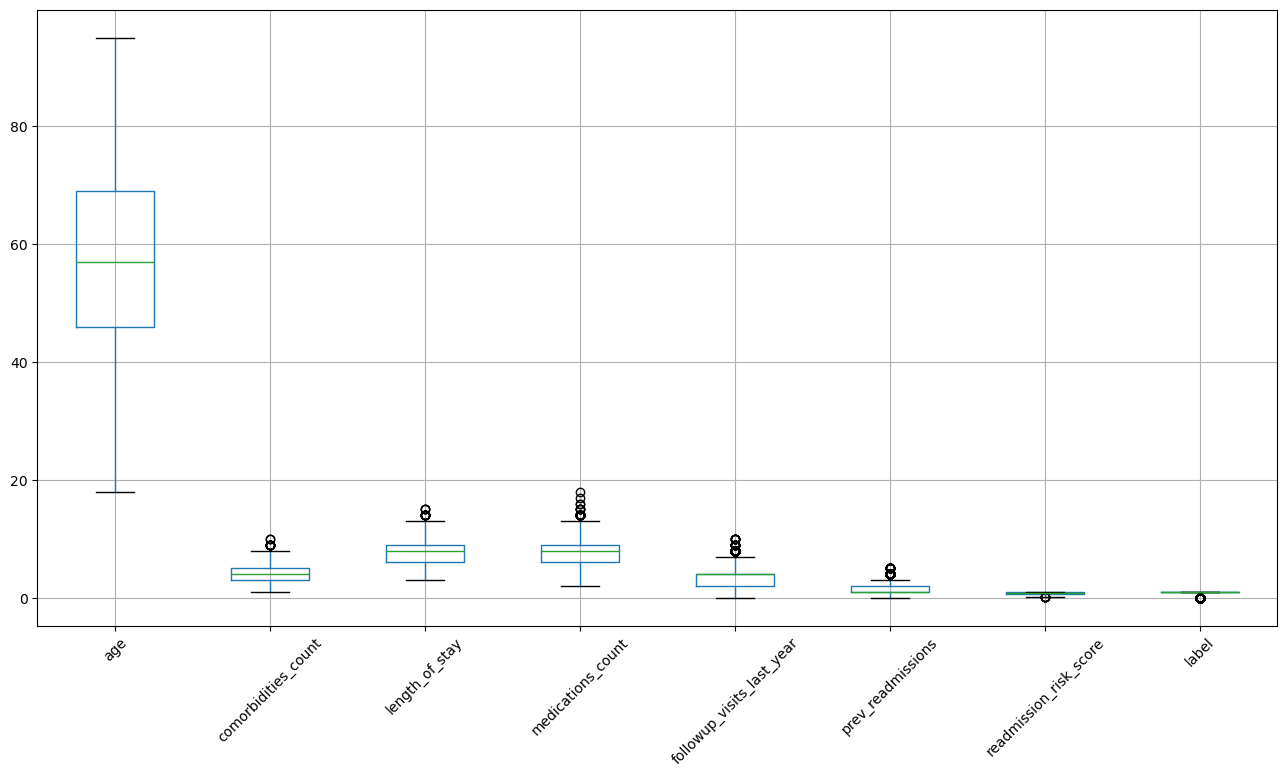

In [28]:
# Box plots of nnumeric values

import matplotlib.pyplot as plt

df.boxplot(figsize=(16,8))
plt.xticks(rotation=45)

### Interpretation

The boxplots provide a summary of the distribution, median, variability, and potential outliers for each numerical variable in the dataset. The median values (green lines) indicate the central tendency of each feature, while the boxes represent the interquartile range (IQR), showing where the middle 50% of observations fall. The whiskers extend to observations within 1.5 times the IQR, and points beyond the whiskers represent potential outliers.

The **age** variable exhibits the greatest variability, reflecting a broad range of patient ages included in the dataset. Several variables, including **comorbidities_count**, **length_of_stay**, **medications_count**, **followup_visits_last_year**, and **prev_readmissions**, contain observations outside the whiskers. These values likely represent patients with more complex medical histories or increased healthcare utilization rather than data entry errors.

The **readmission_risk_score** and **label** variables display relatively little variation because both are constrained by their respective scales. The binary nature of the **label** variable (0 = not readmitted, 1 = readmitted) naturally limits its distribution.

Overall, the boxplots indicate that while several variables contain potential outliers, these observations appear to be clinically plausible and may represent important high-risk patient populations. Therefore, these values will be retained for further investigation during the machine learning phase rather than removed during preprocessing.


<Axes: >

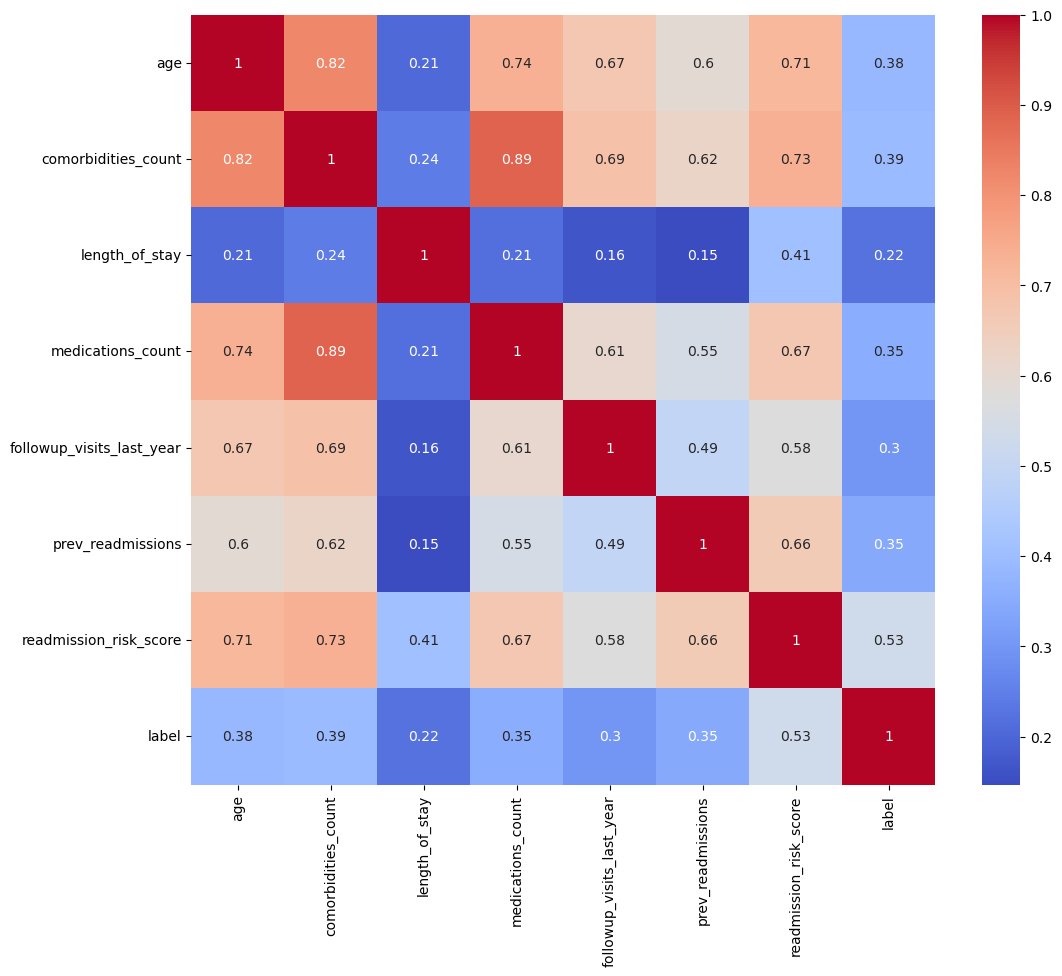

In [30]:
# Correlation matrix to see which varables are moving togeather
# Instll seaborn, uncomment if needed
#!pip install seaborn

import seaborn as sns

plt.figure(figsize=(12,10))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

### Interpretation

The correlation heatmap illustrates the strength of the linear relationships between the numerical variables in the dataset. Correlation coefficients range from **-1** (strong negative relationship) to **1** (strong positive relationship), with values closer to zero indicating little or no linear relationship.

Several variables exhibit strong positive correlations. The strongest relationship is between **comorbidities_count** and **medications_count** (0.89), suggesting that patients with more underlying medical conditions typically require a greater number of medications. Additionally, **age** is strongly correlated with **comorbidities_count** (0.82), indicating that older patients tend to have more chronic health conditions.

The target variable, **label** (30-day readmission), demonstrates its strongest relationship with **readmission_risk_score** (0.53), followed by weaker positive correlations with **comorbidities_count** (0.39), **age** (0.38), **medications_count** (0.35), and **previous_readmissions** (0.35). These findings suggest that patients with higher clinical risk scores, multiple medical conditions, and a history of previous admissions are more likely to experience hospital readmission.

Most other relationships are moderate or weak. For example, **length_of_stay** has relatively low correlations with the target variable (0.22) and with most other features, indicating that hospital stay duration alone may not be a strong predictor of readmission within this dataset.

Overall, the heatmap indicates that several variables are associated with one another, particularly those related to patient health status. These relationships will help guide feature selection during the machine learning phase while also highlighting variables that may exhibit multicollinearity.

Although several variables are highly correlated with one another (for example, age, comorbidities_count, and medications_count), none exhibit perfect correlation. These features will be evaluated further during feature selection to determine whether highly correlated predictors should be retained, transformed, or removed to reduce multicollinearity.

In [88]:
# Relationship Between Comorbidities and Hospital Readmission

pd.crosstab(
    df['comorbidities_count'],
    df['label'],
    normalize='index'
)

label,0,1
comorbidities_count,,
1,0.785714,0.214286
2,0.610487,0.389513
3,0.386842,0.613158
4,0.249479,0.750521
5,0.082143,0.917857
6,0.038198,0.961802
7,0.037736,0.962264
8,0.028571,0.971429
9,0.076923,0.923077


### Interpretation

This cross-tabulation summarizes the relationship between the number of patient comorbidities and 30-day hospital readmission. Each row represents a specific number of comorbidities, while the values indicate the proportion of patients who were not readmitted (label = 0) and those who were readmitted (label = 1).

A clear trend is observed throughout the table. As the number of comorbidities increases, the proportion of patients who are readmitted also increases. Patients with only one comorbidity have approximately a **21%** readmission rate, whereas patients with five or more comorbidities experience readmission rates greater than **90%**. Patients with ten recorded comorbidities were readmitted in every observed case within this dataset.

These findings suggest that the number of comorbidities is strongly associated with hospital readmission and may be an important predictive feature during model development. Clinically, this relationship is reasonable because patients with multiple chronic health conditions often require more complex care and are at greater risk for complications following discharge.

Although this relationship is compelling, it should be interpreted cautiously because the dataset is synthetic. Additional analysis using real-world healthcare data would be necessary to determine whether this pattern generalizes to actual patient populations.

In [34]:
print(df['label'].value_counts())
print(df['label'].value_counts(normalize=True) * 100)

label
1    6183
0    1817
Name: count, dtype: int64
label
1    77.2875
0    22.7125
Name: proportion, dtype: float64


### Interpretation

The target variable represents whether a patient was readmitted within 30 days of discharge, where **1 indicates a readmission** and **0 indicates no readmission**. Examining the class distribution is an important step because it helps determine whether the dataset is balanced and whether additional preprocessing techniques may be required during model development.

The dataset contains **6,183 patients (77.29%)** who were readmitted and **1,817 patients (22.71%)** who were not readmitted. This indicates that the target variable is moderately imbalanced, with the majority of observations belonging to the readmitted class.

Although the imbalance is not severe, relying solely on accuracy to evaluate predictive models could produce misleading results. Therefore, additional evaluation metrics such as **precision, recall, F1-score, and ROC-AUC** will be considered during the machine learning phase to provide a more comprehensive assessment of model performance.

Overall, the target distribution appears appropriate for supervised binary classification and provides a solid foundation for developing predictive models of hospital readmission.

# Potential Stakeholders

The findings from this analysis may benefit several healthcare stakeholders, including:

- Hospital administrators seeking to reduce readmission rates and improve quality metrics.
- Physicians responsible for discharge planning and patient follow-up.
- Care coordinators identifying patients requiring additional support after discharge.
- Healthcare researchers studying factors associated with patient readmissions.
- Insurance providers interested in reducing avoidable healthcare costs.

Each stakeholder may use the results differently, but all share a common interest in improving patient outcomes while reducing unnecessary hospital readmissions.

# Potential Application

The long-term objective of this project is to develop a predictive model capable of estimating the likelihood of a patient's readmission within 30 days of discharge. Such a model could be incorporated into electronic health record systems to identify high-risk patients before discharge, allowing healthcare providers to implement additional interventions such as follow-up appointments, medication reviews, or case management.

# Dataset Selection and Justification

This dataset was selected because it contains a sufficient number of observations and a diverse collection of demographic and clinical variables relevant to hospital readmissions. The dataset contains no missing values or duplicate records and provides an appropriate foundation for exploratory data analysis and predictive modeling.

Additionally, the binary target variable makes the dataset well suited for supervised classification techniques that will be explored in later phases of this project.

# Limitations

Several limitations should be considered when interpreting the results of this analysis.

- The dataset is synthetic and may not fully represent real-world hospital populations.
- Some important clinical variables may not be available, including laboratory values and physician notes.
- The methodology used to generate the synthetic data is unknown.
- The variable `readmission_risk_score` may introduce data leakage if it incorporates information unavailable at prediction time.
- Findings from this analysis should therefore be interpreted as exploratory rather than directly applicable to clinical decision making.

# Target Audience and Dissemination

The intended audience for this analysis includes healthcare administrators, clinicians, quality improvement teams, and healthcare researchers. Results may be communicated through technical reports, interactive dashboards, research presentations, or clinical decision support systems. The ultimate goal is to provide actionable insights that support improved patient outcomes and reduced hospital readmissions.

# Future Improvements

Future work may improve this analysis by incorporating real hospital datasets, additional patient characteristics, medication histories, laboratory results, and socioeconomic factors. Additional machine learning algorithms may also be evaluated and compared to determine which models provide the highest predictive performance while maintaining interpretability.

# Conclusion

The exploratory data analysis demonstrated that the selected dataset is suitable for continued investigation into hospital readmissions. The dataset is complete, contains no duplicate records, and includes a variety of demographic and clinical variables that may contribute to predicting patient readmission. The findings from this exploratory phase establish a strong foundation for the next stage of the project, where machine learning models will be developed and evaluated to predict 30-day hospital readmissions.

# Feature Selection Considerations

This variable appears to represent an overall assessment of a patient's likelihood of hospital readmission. Because the methodology used to calculate this score is not documented, there is a possibility that it incorporates information that may not be available at the time a prediction would normally be made. If so, including this feature during model training could introduce **data leakage**, resulting in overly optimistic model performance.

To evaluate the impact of this variable, two predictive models will be developed:

1. **Model A:** Includes all available features, including `readmission_risk_score`.
2. **Model B:** Excludes `readmission_risk_score` to determine how well the remaining patient demographic and clinical variables predict hospital readmission.

The performance of both models will be compared to assess whether the inclusion of `readmission_risk_score` provides legitimate predictive value or introduces information that would not be available in a real-world prediction scenario.

This comparison will also provide insight into the importance of feature selection and the potential effects of data leakage in machine learning models.

> **Note:** Since this dataset is synthetic, the origin of the `readmission_risk_score` is unknown. Rather than assuming the feature is appropriate or inappropriate for modeling, both approaches will be evaluated and compared.
During the initial exploration of the dataset, one feature was identified that warrants further investigation: **`readmission_risk_score`**.